In [1]:
from superfv import HydroSolver
from superfv.initial_conditions import square

import matplotlib.pyplot as plt

from functools import partial

In [2]:
sim0 = HydroSolver(
    ic=partial(square, rho_min=1, rho_max=2, P=1, vx=1),
    PAD_bounds={"rho": (1, None), "P": (1e-12, None)},
    nx=100,
    p=7,
    use_ZS=True,
    adaptive_dt=True,
    lazy_primitive_mode="adaptive",
)

sim0.run(20.0)

sim0_rho_min = min(x.rho_min for x in sim0.step_history)
print(sim0_rho_min - 1)

/home/jp7427/Desktop/superfv/superfv/hydro_solver.py:581: UserWarning: PAD lower bound for 'rho' is 1, which is different from the hydro parameter rho_min=1e-12.
  warnings.warn(


SuperFV: 5889 steps | t=2.00e+01/2.00e+01, dt=1.44e-04 | rho_min=1.00e+00 | E_cons=0.00e+00 | wall=2.92e+01s (done)
-6.661338147750939e-16


In [3]:
sim1 = HydroSolver(
    ic=partial(square, rho_min=1, rho_max=2, P=1, vx=1),
    PAD_bounds={"rho": (1, None), "P": (1e-12, None)},
    nx=100,
    p=7,
    use_MOOD=True,
    positivity_guard=False,
    lazy_primitive_mode="full",
    fallback_cascade="first_order",
    rtol=1e-14,
    max_revs=2,
)
sim1.run(20.0)

sim1_rho_min = min(x.rho_min for x in sim1.step_history)
print(sim1_rho_min - 1)

SuperFV: 5458 steps | t=2.00e+01/2.00e+01, dt=2.76e-03 | rho_min=1.00e+00 | E_cons=0.00e+00 | wall=2.62e+01s (done)
-3.3306690738754696e-16


In [4]:
sim2 = HydroSolver(
    ic=partial(square, rho_min=1, rho_max=2, P=1, vx=1),
    PAD_bounds={"rho": (1, None), "P": (1e-12, None)},
    nx=100,
    p=7,
    use_MOOD=True,
    positivity_guard=False,
    lazy_primitive_mode="full",
    fallback_cascade="muscl0",
    MUSCL_limiter="moncen",
    rtol=1e-14,
    max_revs=2,
)
sim2.run(20.0)

sim2_rho_min = min(x.rho_min for x in sim2.step_history)
print(sim2_rho_min - 1)

SuperFV: 5459 steps | t=2.00e+01/2.00e+01, dt=1.46e-04 | rho_min=1.00e+00 | E_cons=0.00e+00 | wall=2.74e+01s (done)
-1.4432899320127035e-15


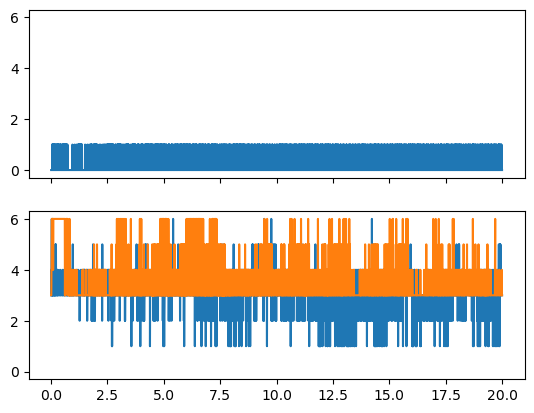

In [5]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

def plot_timeseries(ax, sim, x):
    t = sim.step_history.get_history("t_sim")
    if x == "n_MOOD_revisions":
        sum_list = [sum(y.n_MOOD_revisions for y in x.substeps) for x in sim.step_history]
        ax.plot(t, sum_list)
    else:
        ax.plot(t, sim.step_history.get_history(x))

plot_timeseries(axs[0], sim0, "n_dt_revisions")
plot_timeseries(axs[1], sim1, "n_MOOD_revisions")
plot_timeseries(axs[1], sim2, "n_MOOD_revisions")
    
# plot_timeseries(sim0, axs[0], "n_dt_revisions")
# plot_timeseries(sim1, axs[1], "nfine_MOOD_iters")
# plot_timeseries(sim2, axs[1], "nfine_MOOD_iters")

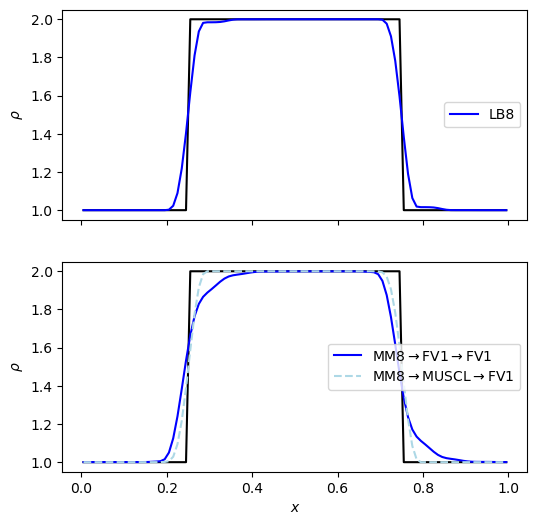

In [6]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(6, 6))

axs[0].set_ylabel(r"$\rho$")
axs[1].set_ylabel(r"$\rho$")
axs[1].set_xlabel(r"$x$")

axs[0].plot(sim0.mesh.centers[0], sim0.snapshot_history[0].u[sim0.idx("rho"), :, 0, 0], color="k")
axs[1].plot(sim0.mesh.centers[0], sim0.snapshot_history[0].u[sim0.idx("rho"), :, 0, 0], color="k")

axs[0].plot(sim0.mesh.centers[0], sim0.snapshot_history[-1].u[sim0.idx("rho"), :, 0, 0], color="blue", label=r"$8^{\mathrm{th}}$-order $\mathit{a\ priori}$")

axs[1].plot(sim1.mesh.centers[0], sim1.snapshot_history[-1].u[sim1.idx("rho"), :, 0, 0], color="blue", label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}$" "\n" r"$\rightarrow 1^{\mathrm{st}}$-order unlimited $\rightarrow 1^{\mathrm{st}}$-order unlimited")
axs[1].plot(sim2.mesh.centers[0], sim2.snapshot_history[-1].u[sim2.idx("rho"), :, 0, 0], color="lightblue", linestyle="--", label=r"$8^{\mathrm{th}}$-order $\mathit{a\ posteriori}$" "\n" r"$\rightarrow$MUSCL$\rightarrow 1^{\mathrm{st}}$-order unlimited")

axs[0].legend(loc="center right")
axs[1].legend(loc="center right")

In [7]:
fig.savefig("square.pdf")